# 02 — Market Cleaning

Loads the raw option data from NB01 and applies a sequence of filters to remove
illiquid, stale, and unreliable quotes before IV estimation in NB03.

**Inputs** from `data/raw/`
- `options_raw.csv`
- `download_metadata.csv`
- `selected_expiries.csv`

**Outputs** saved to `data/processed/`
- `options_clean.csv` — filtered, enriched option data ready for IV solving

**Filter sequence applied**
1. Drop rows missing critical fields (e.g. bid, ask, ttm, strike, mid, spot or optiontype)
2. Minimum bid and mid price
3. Ask strictly greater than bid
4. Positive time to maturity
5. Open interest > 0
6. Strike within ±15 % of spot
7. Bid-ask spread / mid ≤ 50 %
8. Trade staleness ≤ 5 calendar days

## 1. Imports and configuration

In [115]:
# Standard library
import tomllib
from pathlib import Path

# Numerical and data libraries
import numpy as np
import pandas as pd

# Plotting — used for diagnostic charts at the end of the notebook
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (12, 4)
plt.rcParams["axes.grid"]      = True
plt.rcParams["axes.titlesize"] = 12
plt.rcParams["axes.labelsize"] = 10

In [116]:
# Load filtering parameters from config.toml.
# All thresholds live here so they can be tuned without touching the notebook.

with open("config.toml", "rb") as f:
    config = tomllib.load(f)

ticker                  = config["ticker"]
min_bid                 = config["min_bid"]
min_mid                 = config["min_mid"]
max_spread_ratio        = config["max_spread_ratio"]
strike_lower_multiplier = config["strike_lower_multiplier"]
strike_upper_multiplier = config["strike_upper_multiplier"]

print("Ticker                  :", ticker)
print("Min bid                 :", min_bid)
print("Min mid                 :", min_mid)
print("Max spread / mid        :", max_spread_ratio)
print("Strike lower multiplier :", strike_lower_multiplier)
print("Strike upper multiplier :", strike_upper_multiplier)

Ticker                  : GOOG
Min bid                 : 0.05
Min mid                 : 0.05
Max spread / mid        : 0.5
Strike lower multiplier : 0.85
Strike upper multiplier : 1.15


## 2. Load raw data

In [117]:
# Load raw option data and metadata produced by NB01.
options_raw       = pd.read_csv("data/raw/options_raw.csv")
metadata          = pd.read_csv("data/raw/download_metadata.csv")
selected_expiries = pd.read_csv("data/raw/selected_expiries.csv")

print("Raw options shape    :", options_raw.shape)
print("Metadata shape       :", metadata.shape)
print("Selected expiries    :", selected_expiries.shape)

options_raw.head()

Raw options shape    : (673, 23)
Metadata shape       : (1, 9)
Selected expiries    : (5, 3)


,contractsymbol,lasttradedate,strike,lastprice,bid,ask,change,percentchange,volume,openinterest,...,currency,option_type,ticker,expiration,valuation_date,mid,days_to_expiry,ttm,spot,moneyness
0,GOOG260327C00170000,2026-03-02 20:44:20+00:00,170.0,135.72,135.40,138.95,0.0,0.0,NaN,4,...,USD,call,GOOG,2026-03-27,2026-03-16 04:00:00,137.175,10,0.027397,304.420013,0.558439
1,GOOG260327C00175000,2026-02-27 18:35:37+00:00,175.0,131.05,130.40,133.95,0.0,0.0,10.0,35,...,USD,call,GOOG,2026-03-27,2026-03-16 04:00:00,132.175,10,0.027397,304.420013,0.574864
2,GOOG260327C00180000,2026-02-26 16:39:39+00:00,180.0,127.19,125.40,129.05,0.0,0.0,6.0,7,...,USD,call,GOOG,2026-03-27,2026-03-16 04:00:00,127.225,10,0.027397,304.420013,0.591288
3,GOOG260327C00185000,2026-02-23 18:38:53+00:00,185.0,129.96,120.40,124.10,0.0,0.0,1.0,3,...,USD,call,GOOG,2026-03-27,2026-03-16 04:00:00,122.250,10,0.027397,304.420013,0.607713
4,GOOG260327C00195000,2026-02-27 19:43:16+00:00,195.0,112.15,110.35,114.00,0.0,0.0,3.0,3,...,USD,call,GOOG,2026-03-27,2026-03-16 04:00:00,112.175,10,0.027397,304.420013,0.640562


## 3. Parse and cast columns

In [118]:
# Parse date columns — they arrive as strings from CSV.
options_raw["valuation_date"] = pd.to_datetime(options_raw["valuation_date"])
options_raw["expiration"]     = pd.to_datetime(options_raw["expiration"])

# Coerce numeric columns; anything that cannot be parsed becomes NaN
# and will be caught by the missing-value filter below.
numeric_cols = [
    "strike", "bid", "ask", "mid", "lastprice", "volume",
    "open_interest", "impliedvolatility", "days_to_expiry",
    "ttm", "spot", "moneyness"
]
for col in numeric_cols:
    if col in options_raw.columns:
        options_raw[col] = pd.to_numeric(options_raw[col], errors="coerce")

options_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 673 entries, 0 to 672
Data columns (total 23 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   contractsymbol     673 non-null    str           
 1   lasttradedate      673 non-null    str           
 2   strike             673 non-null    float64       
 3   lastprice          673 non-null    float64       
 4   bid                673 non-null    float64       
 5   ask                673 non-null    float64       
 6   change             673 non-null    float64       
 7   percentchange      673 non-null    float64       
 8   volume             649 non-null    float64       
 9   openinterest       673 non-null    int64         
 10  impliedvolatility  673 non-null    float64       
 11  inthemoney         673 non-null    bool          
 12  contractsize       673 non-null    str           
 13  currency           673 non-null    str           
 14  option_type        67

## 4. Pre-filter diagnostics

In [119]:
# Snapshot of the raw dataset before any filtering.
# Use this to understand what you are starting with.

raw_summary = pd.Series({
    "rows"        : len(options_raw),
    "num_expiries": options_raw["expiration"].nunique(),
    "num_calls"   : int((options_raw["option_type"] == "call").sum()),
    "num_puts"    : int((options_raw["option_type"] == "put").sum()),
    "min_strike"  : float(options_raw["strike"].min()),
    "max_strike"  : float(options_raw["strike"].max()),
    "min_bid"     : float(options_raw["bid"].min()),
    "max_bid"     : float(options_raw["bid"].max()),
    "min_mid"     : float(options_raw["mid"].min()),
    "max_mid"     : float(options_raw["mid"].max()),
    "missing_iv"  : int(options_raw["impliedvolatility"].isna().sum()),
    "zero_oi" : int((options_raw["openinterest"] == 0).sum()) if "openinterest" in options_raw.columns else "n/a",
})

raw_summary

rows            673.000
num_expiries      5.000
num_calls       353.000
num_puts        320.000
min_strike       75.000
max_strike      500.000
min_bid           0.000
max_bid         247.900
min_mid           0.005
max_mid         249.450
missing_iv        0.000
zero_oi          41.000
dtype: float64

## 5. Apply filters

Each filter is applied in sequence. A row-count tracker records how many rows
each step removes so the attrition is fully auditable.

In [120]:
# Initialise the clean dataset and the attrition tracker.
options_clean = options_raw.copy()
attrition = {"raw": len(options_clean)}

In [121]:
# ── Filter 1: drop rows missing any critical field ───────────────────────────
# Without these columns a row cannot be priced or used in IV solving.
critical_cols = ["strike", "bid", "ask", "mid", "ttm", "spot", "option_type"]
options_clean = options_clean.dropna(subset=critical_cols).copy()
attrition["missing_critical"] = len(options_clean)
print("After missing critical fields :", len(options_clean))

After missing critical fields : 673


In [122]:
# ── Filter 2: minimum bid and mid price ──────────────────────────────────────
# Quotes with negligible bid or mid are effectively untradeable and their
# prices carry no reliable market information.
options_clean = options_clean[options_clean["bid"] >= min_bid].copy()
options_clean = options_clean[options_clean["mid"] >= min_mid].copy()
attrition["min_bid_mid"] = len(options_clean)
print("After min bid / mid filter    :", len(options_clean))

After min bid / mid filter    : 587


In [123]:
# ── Filter 3: ask > bid ───────────────────────────────────────────────────────
# A crossed or flat market (ask ≤ bid) indicates a stale or erroneous quote.
options_clean = options_clean[options_clean["ask"] > options_clean["bid"]].copy()
attrition["ask_gt_bid"] = len(options_clean)
print("After ask > bid filter        :", len(options_clean))

After ask > bid filter        : 586


In [124]:
# ── Filter 4: positive time to maturity ──────────────────────────────────────
# Options that have already expired or expire on the valuation date are useless
# for pricing and IV analysis.
options_clean = options_clean[options_clean["ttm"] > 0].copy()
attrition["positive_ttm"] = len(options_clean)
print("After positive TTM filter     :", len(options_clean))

After positive TTM filter     : 586


In [125]:
# ── Filter 5: open interest > 0 ──────────────────────────────────────────────
# Zero open interest means no outstanding contracts exist.
# These quotes are typically stale listings with no active market.
# options_clean = options_clean[options_clean["openinterest"] > 0].copy()
# attrition["open_interest"] = len(options_clean)
if "openinterest" in options_clean.columns:
    options_clean = options_clean[options_clean["openinterest"] > 0].copy()
    attrition["open_interest"] = len(options_clean)
    print("After open interest filter    :", len(options_clean))
else:
    print("WARNING: openinterest column not found — filter skipped.")
    attrition["open_interest"] = len(options_clean)


After open interest filter    : 546


In [126]:
# ── Filter 6: strike within ±15 % of spot ────────────────────────────────────
# Very deep ITM and OTM options have poor liquidity, wide spreads, and
# their IVs are unreliable, which distorts the smile estimation in NB03.
# Spot is read from the metadata CSV rather than from a row value
# to avoid dependence on row ordering.
spot = float(metadata["latest_spot"].iloc[0])

strike_lower_bound = spot * strike_lower_multiplier
strike_upper_bound = spot * strike_upper_multiplier

options_clean = options_clean[
    (options_clean["strike"] >= strike_lower_bound) &
    (options_clean["strike"] <= strike_upper_bound)
].copy()

attrition["strike_band"] = len(options_clean)
print(f"Spot: {spot}  |  Strike band: [{strike_lower_bound:.2f}, {strike_upper_bound:.2f}]")
print("After strike band filter      :", len(options_clean))

Spot: 304.4200134277344  |  Strike band: [258.76, 350.08]
After strike band filter      : 211


In [127]:
# ── Filter 7: bid-ask spread / mid ≤ max_spread_ratio ────────────────────────
# A large spread relative to the mid price signals an illiquid quote whose
# mid price may not reflect the true option value.
options_clean["spread"]          = options_clean["ask"] - options_clean["bid"]
options_clean["spread_over_mid"] = options_clean["spread"] / options_clean["mid"]

options_clean = options_clean[
    options_clean["spread_over_mid"] <= max_spread_ratio
].copy()

attrition["spread_ratio"] = len(options_clean)
print("After spread ratio filter     :", len(options_clean))

After spread ratio filter     : 211


In [128]:
# ── Filter 8: trade staleness ≤ 5 calendar days ──────────────────────────────
# Options where the last recorded trade is more than 5 days old may not
# reflect current market conditions and can corrupt the IV surface.
# We parse the lasttradedate column (tz-aware from yfinance) and strip
# the timezone so arithmetic with the tz-naive valuation_date works cleanly.

if "lasttradedate" in options_clean.columns:
    options_clean["lasttradedate"] = pd.to_datetime(
        options_clean["lasttradedate"], utc=True, errors="coerce"
    ).dt.tz_convert(None)

    reference_date = pd.Timestamp.today().normalize()  # Use current date as reference for staleness

    options_clean["trade_age_days"] = (
        reference_date
        - options_clean["lasttradedate"].dt.normalize()
    ).dt.days

    options_clean = options_clean[options_clean["trade_age_days"] <= 5].copy()
    attrition["staleness"] = len(options_clean)
    print("After staleness filter        :", len(options_clean))
else:
    print("WARNING: lasttradedate column not found — staleness filter skipped.")
    attrition["staleness"] = len(options_clean)

After staleness filter        : 193


## 6. Filter attrition table

In [129]:
# Show exactly how many rows each filter removed.
# This is the primary QC tool for the cleaning pipeline —
# if a filter removes an unexpectedly large number of rows, investigate before continuing.

attrition_df = pd.DataFrame({
    "stage"    : list(attrition.keys()),
    "rows_remaining": list(attrition.values()),
})
attrition_df["rows_removed"] = attrition_df["rows_remaining"].shift(1) - attrition_df["rows_remaining"]
attrition_df["rows_removed"] = attrition_df["rows_removed"].fillna(0).astype(int)
attrition_df["pct_removed"]  = (
    attrition_df["rows_removed"] / attrition_df["rows_remaining"].iloc[0] * 100
).round(2)

attrition_df

,stage,rows_remaining,rows_removed,pct_removed
0,raw,673,0,0.00
1,missing_critical,673,0,0.00
2,min_bid_mid,587,86,12.78
3,ask_gt_bid,586,1,0.15
4,positive_ttm,586,0,0.00
5,open_interest,546,40,5.94
6,strike_band,211,335,49.78
7,spread_ratio,211,0,0.00
8,staleness,193,18,2.67


## 7. Enrich cleaned data

In [130]:
# Log-moneyness ln(K/S) — used as the x-axis for smile analysis in NB03.
# Symmetric around 0: negative = OTM put / ITM call, positive = OTM call / ITM put.
options_clean["log_moneyness"] = np.log(options_clean["strike"] / options_clean["spot"])

# Maturity bucket labels — useful for grouping and plotting across expiries.
conditions = [
    options_clean["days_to_expiry"] <= 14,
    (options_clean["days_to_expiry"] > 14)  & (options_clean["days_to_expiry"] <= 60),
    (options_clean["days_to_expiry"] > 60)  & (options_clean["days_to_expiry"] <= 150),
    (options_clean["days_to_expiry"] > 150) & (options_clean["days_to_expiry"] <= 270),
    options_clean["days_to_expiry"] > 270,
]
labels = ["weekly", "short", "medium", "long", "one_year"]
options_clean["maturity_bucket"] = np.select(conditions, labels, default="other")

# Sort for consistent ordering in all downstream notebooks.
options_clean = options_clean.sort_values(
    by=["expiration", "option_type", "strike"]
).reset_index(drop=True)

print("Final cleaned dataset shape:", options_clean.shape)
options_clean.head()

Final cleaned dataset shape: (193, 28)


,contractsymbol,lasttradedate,strike,lastprice,bid,ask,change,percentchange,volume,openinterest,...,mid,days_to_expiry,ttm,spot,moneyness,spread,spread_over_mid,trade_age_days,log_moneyness,maturity_bucket
0,GOOG260327C00260000,2026-03-12 19:35:13,260.0,45.48,46.40,48.35,0.000000,0.000000,5.0,25,...,47.375,10,0.027397,304.420013,0.854083,1.95,0.041161,5,-0.157727,weekly
1,GOOG260327C00265000,2026-03-16 19:01:15,265.0,39.66,41.50,43.30,0.000000,0.000000,2.0,19,...,42.400,10,0.027397,304.420013,0.870508,1.80,0.042453,1,-0.138679,weekly
2,GOOG260327C00270000,2026-03-16 19:18:15,270.0,34.62,36.55,38.40,0.000000,0.000000,16.0,14,...,37.475,10,0.027397,304.420013,0.886932,1.85,0.049366,1,-0.119986,weekly
3,GOOG260327C00275000,2026-03-17 15:46:14,275.0,31.52,31.70,33.55,2.370001,8.130363,6.0,22,...,32.625,10,0.027397,304.420013,0.903357,1.85,0.056705,0,-0.101637,weekly
4,GOOG260327C00277500,2026-03-17 15:46:14,277.5,29.07,29.25,30.90,4.150000,16.653290,6.0,1,...,30.075,10,0.027397,304.420013,0.911570,1.65,0.054863,0,-0.092587,weekly


## 8. Diagnostic plots

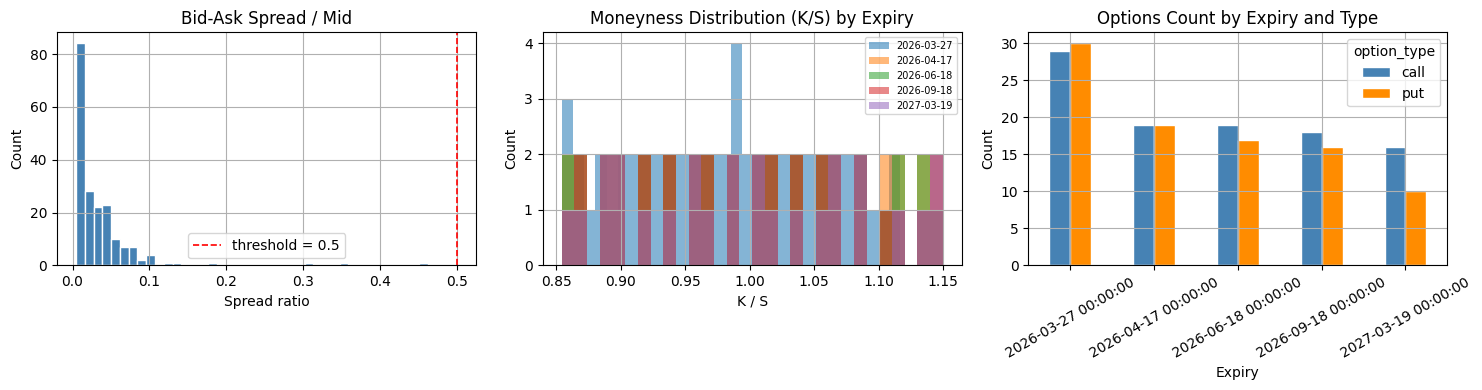

In [131]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Plot 1: bid-ask spread / mid distribution
# Should be concentrated below max_spread_ratio with no long right tail.
options_clean["spread_over_mid"].hist(bins=40, ax=axes[0], color="steelblue", edgecolor="white")
axes[0].axvline(max_spread_ratio, color="red", linestyle="--", linewidth=1.2, label=f"threshold = {max_spread_ratio}")
axes[0].set_title("Bid-Ask Spread / Mid")
axes[0].set_xlabel("Spread ratio")
axes[0].set_ylabel("Count")
axes[0].legend()

# Plot 2: moneyness distribution by expiry
# All expiries should be centred near 1.0 (ATM) within the ±15 % band.
for expiry, grp in options_clean.groupby("expiration"):
    grp["moneyness"].hist(bins=30, alpha=0.55, ax=axes[1], label=str(expiry.date()))
axes[1].set_title("Moneyness Distribution (K/S) by Expiry")
axes[1].set_xlabel("K / S")
axes[1].set_ylabel("Count")
axes[1].legend(fontsize=7)

# Plot 3: option count by expiry and type
expiry_counts = (
    options_clean
    .groupby(["expiration", "option_type"])
    .size()
    .unstack(fill_value=0)
)
expiry_counts.plot(kind="bar", ax=axes[2], color=["steelblue", "darkorange"], edgecolor="white")
axes[2].set_title("Options Count by Expiry and Type")
axes[2].set_xlabel("Expiry")
axes[2].set_ylabel("Count")
axes[2].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.savefig("outputs/plots/notebook2_diagnostics.png", dpi=150, bbox_inches="tight")
plt.show()

## 9. Post-filter summary

In [132]:
# Side-by-side comparison of raw vs cleaned dataset.
clean_summary = pd.Series({
    "raw_rows"           : len(options_raw),
    "clean_rows"         : len(options_clean),
    "rows_removed"       : len(options_raw) - len(options_clean),
    "pct_removed"        : round(100 * (len(options_raw) - len(options_clean)) / len(options_raw), 2),
    "clean_num_expiries" : options_clean["expiration"].nunique(),
    "clean_num_calls"    : int((options_clean["option_type"] == "call").sum()),
    "clean_num_puts"     : int((options_clean["option_type"] == "put").sum()),
    "clean_min_strike"   : float(options_clean["strike"].min()),
    "clean_max_strike"   : float(options_clean["strike"].max()),
    "clean_min_ttm"      : float(options_clean["ttm"].min()),
    "clean_max_ttm"      : float(options_clean["ttm"].max()),
})

clean_summary

raw_rows              673.000000
clean_rows            193.000000
rows_removed          480.000000
pct_removed            71.320000
clean_num_expiries      5.000000
clean_num_calls       101.000000
clean_num_puts         92.000000
clean_min_strike      260.000000
clean_max_strike      350.000000
clean_min_ttm           0.027397
clean_max_ttm           1.005479
dtype: float64

In [133]:
# Calls and puts per expiry — confirms balanced coverage across the term structure.
expiry_type_counts = (
    options_clean
    .groupby(["expiration", "option_type"])
    .size()
    .unstack(fill_value=0)
)

expiry_type_counts

option_type,call,put
expiration,,
2026-03-27,29,30
2026-04-17,19,19
2026-06-18,19,17
2026-09-18,18,16
2027-03-19,16,10


## 10. Save outputs

In [134]:
# Save the cleaned options dataset for NB03.
clean_file = Path("data/processed/options_clean.csv")
options_clean.to_csv(clean_file, index=False)
print("Saved:", clean_file)

# Save summary tables for reporting.
clean_summary.to_csv("outputs/tables/notebook2_clean_summary.csv", header=False)
expiry_type_counts.to_csv("outputs/tables/notebook2_expiry_type_counts.csv")
attrition_df.to_csv("outputs/tables/notebook2_attrition.csv", index=False)

print("Saved: outputs/tables/notebook2_clean_summary.csv")
print("Saved: outputs/tables/notebook2_expiry_type_counts.csv")
print("Saved: outputs/tables/notebook2_attrition.csv")

Saved: data/processed/options_clean.csv
Saved: outputs/tables/notebook2_clean_summary.csv
Saved: outputs/tables/notebook2_expiry_type_counts.csv
Saved: outputs/tables/notebook2_attrition.csv


## 11. Final inspection

In [135]:
# Random sample — visually confirm strikes, prices, and dates look sensible.
options_clean.sample(min(10, len(options_clean))).sort_values(
    ["expiration", "option_type", "strike"]
)

,contractsymbol,lasttradedate,strike,lastprice,bid,ask,change,percentchange,volume,openinterest,...,mid,days_to_expiry,ttm,spot,moneyness,spread,spread_over_mid,trade_age_days,log_moneyness,maturity_bucket
7,GOOG260327C00285000,2026-03-13 19:59:00,285.0,19.61,23.05,23.50,0.000000,0.000000,6.0,46,...,23.275,10,0.027397,304.420013,0.936207,0.45,0.019334,4,-0.065919,weekly
8,GOOG260327C00287500,2026-03-17 16:24:42,287.5,20.62,20.50,21.20,1.500000,7.845188,71.0,164,...,20.850,10,0.027397,304.420013,0.944419,0.70,0.033573,0,-0.057186,weekly
25,GOOG260327C00330000,2026-03-17 16:43:52,330.0,0.20,0.19,0.21,-0.040000,-17.391300,359.0,2125,...,0.200,10,0.027397,304.420013,1.084029,0.02,0.100000,0,0.080684,weekly
54,GOOG260327P00322500,2026-03-12 19:22:05,322.5,19.48,15.60,16.85,0.000000,0.000000,NaN,10,...,16.225,10,0.027397,304.420013,1.059392,1.25,0.077042,5,0.057695,weekly
94,GOOG260417P00340000,2026-03-16 19:07:16,340.0,36.05,31.95,34.50,0.000000,0.000000,17.0,455,...,33.225,31,0.084932,304.420013,1.116878,2.55,0.076749,1,0.110537,short
116,GOOG260618P00260000,2026-03-17 15:50:28,260.0,5.22,4.95,5.05,-0.680000,-11.525429,73.0,9007,...,5.000,93,0.254795,304.420013,0.854083,0.10,0.020000,0,-0.157727,medium
141,GOOG260918C00305000,2026-03-17 16:26:32,305.0,33.40,33.35,33.50,0.850002,2.611374,13.0,633,...,33.425,185,0.506849,304.420013,1.001905,0.15,0.004488,0,0.001903,long
142,GOOG260918C00310000,2026-03-17 15:30:27,310.0,30.00,30.75,30.90,1.299999,4.529614,4.0,748,...,30.825,185,0.506849,304.420013,1.018330,0.15,0.004866,0,0.018164,long
152,GOOG260918P00265000,2026-03-16 19:18:58,265.0,12.75,11.60,11.75,0.000000,0.000000,129.0,660,...,11.675,185,0.506849,304.420013,0.870508,0.15,0.012848,1,-0.138679,long
165,GOOG260918P00330000,2026-03-17 15:39:24,330.0,40.10,38.95,39.15,-1.900001,-4.523813,2.0,24064,...,39.050,185,0.506849,304.420013,1.084029,0.20,0.005122,0,0.080684,long
